In [193]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

local_path = r"C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\1-2. [Lead] Triboresistive sensor\1. [Lead] DC TRS\1. 실험자료\260726_DC 규칙 찾아보기\1. 파일 정리\Exp 6_Frequency\No_wait_2N_5.60_Hz.csv"


max value: 0.1594


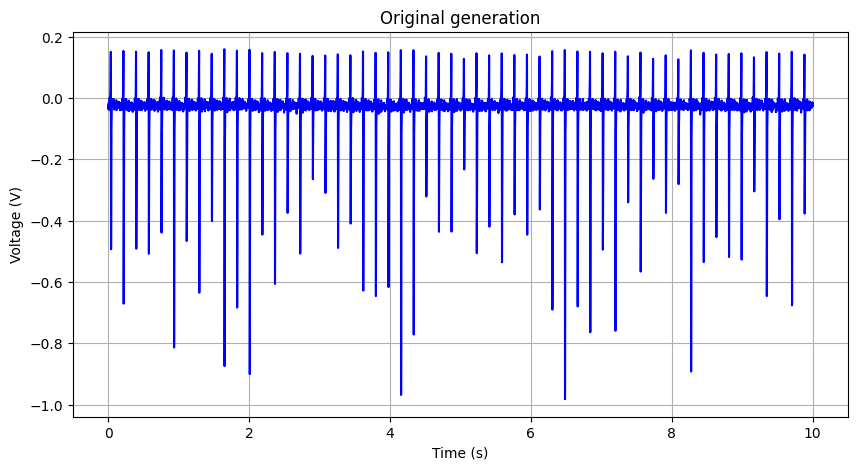

In [194]:
df = pd.read_csv(local_path, header=None, usecols=[0, 1])

#df.iloc[:30, :] = np.nan
df.columns = ["Time", "Voltage"]

# 데이터 형식 변환...글자 -> NaNwwwwwww
df["Time"] = pd.to_numeric(df["Time"], errors='coerce')
df["Voltage"] = pd.to_numeric(df["Voltage"], errors='coerce')

print(f"max value: {df.iloc[:, 1].max(skipna=True):.4f}")

plt.figure(figsize=(10, 5))
plt.plot(df.iloc[:, 0], df.iloc[:, 1], label="AC Voltage", color='b')
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Original generation")
#plt.ylim(-1, 9)
#plt.legend()
plt.grid(True)
plt.show()

In [195]:
# 필터링된 데이터 생성
time_range =(2.95, 3.95)# 단위: 초 ########### MODIFY HERE

Filtered data saved at: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\1-2. [Lead] Triboresistive sensor\1. [Lead] DC TRS\1. 실험자료\260726_DC 규칙 찾아보기\1. 파일 정리\Exp 6_Frequency\Cut_No_wait_2N_5.60_Hz.csv


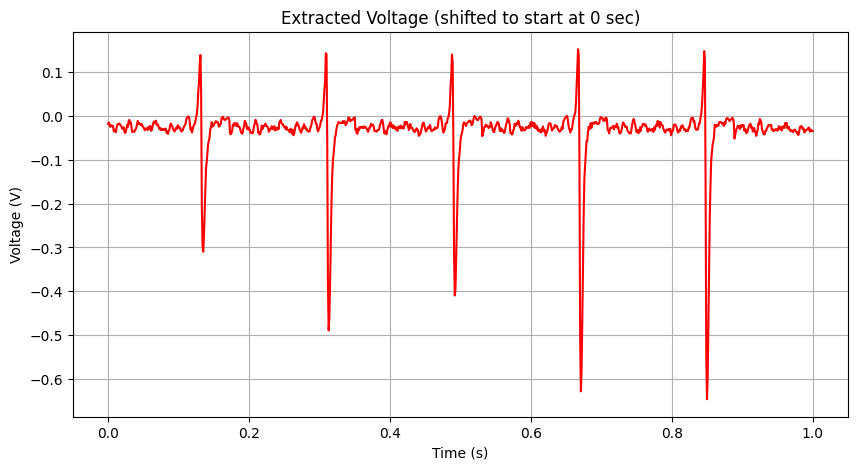

In [196]:
df_filtered = df[(df.iloc[:, 0] >= time_range[0]) & (df.iloc[:, 0] <= time_range[1])].reset_index(drop=True)

# 시간축 0초부터 시작 (단순 이동)
df_filtered.iloc[:, 0] = df_filtered.iloc[:, 0] - df_filtered.iloc[0, 0]

# 기존 local_path에서 폴더 경로 및 원래 파일명 추출
folder_path = os.path.dirname(local_path)
original_filename = os.path.basename(local_path)  # 원래 파일명 가져오기
filtered_file_name = f"Cut_{original_filename}"  # "Cut_" 추가
filtered_file_path = os.path.join(folder_path, filtered_file_name)

# CSV 파일 저장
df_filtered.to_csv(filtered_file_path, index=False, header=False)
print(f"Filtered data saved at: {filtered_file_path}")

# 필터링된 데이터 시각화
plt.figure(figsize=(10, 5))
plt.plot(df_filtered.iloc[:, 0], df_filtered.iloc[:, 1], label="Filtered AC current", color='r')
plt.xlabel("Time (s)")
#plt.ylim(-70,10)
plt.ylabel("Voltage (V)") #Current (µA)
plt.title(f"Extracted Voltage (shifted to start at 0 sec)")
plt.grid(True)
plt.show()
